In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from scipy.optimize import curve_fit

# Cvičení: Lineární a polynomiální regrese

### Úkol 1: Načtěte dataset ze souboru Synthetic dataset.csv. Identifikujte vstupní proměnnou X a cílovou proměnnou Y (podle názvů sloupců v CSV).

In [2]:
file_path = "Datasets/Synthetic_dataset.csv"
df = pd.read_csv(file_path)
print(df.head())

# Select features
X = df["X"].values.reshape(-1, 1)
y = df["Y"].values
# print(X)
# print(y)

          X          Y
0 -3.000000  33.652460
1 -2.979933  32.110669
2 -2.959866  32.589028
3 -2.939799  33.204325
4 -2.919732  30.107067


Úkol 2: Vytvořte bodový graf (scatterplot) Y = f(X). Osa x: vstupní proměnná, osa y: cílová proměnná. Uložte graf do formátu png. Vytvořte bodový graf (scatterplot) Y = f (X ). Osa x : vstupní proměnná, osa y : cílová proměnná. Uložte graf do formátu png.

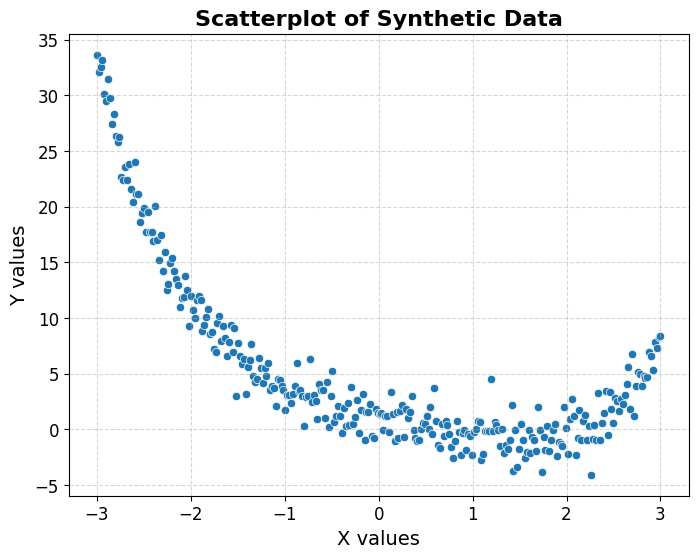

In [3]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="X", y="Y")
plt.xlabel("X values", fontsize=14)
plt.ylabel("Y values", fontsize=14)
plt.title("Scatterplot of Synthetic Data", fontsize=16, fontweight='bold')

# Adjust tick label font sizes
plt.xticks(fontsize=12)  # Set x-axis tick font size
plt.yticks(fontsize=12)  # Set y-axis tick font size

# Grid customization
plt.grid(True, linestyle='--', alpha=0.5)  # Add grid with dashed lines and transparency


plt.show()

### 3. Natrénujte následující regresní modely:
- lineární regresi,
- polynomiální regresi pro stupně d ∈ {2, 3, 4, 5, 6, 7}.

Pro každý model vytvořte predikce ŷ na stejných datech (nebo na testovací množině, pokud provedete rozdělení).

In [4]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin_reg = lin_reg.predict(X_test)


mse_lin = mean_squared_error(y_test, y_pred_lin_reg)
rmse_lin = np.sqrt(mse_lin)
mae_lin = mean_absolute_error(y_test, y_pred_lin_reg)
r2_lin = r2_score(y_test, y_pred_lin_reg)

# rows: different models, columns: different metrics
results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MSE": [mse_lin],
    "RMSE": [rmse_lin],
    "MAE": [mae_lin],
    "R2 Score": [r2_lin]
})
# print(results)


degrees = [2, 3, 4, 5, 6, 7]
y_poly_pred = {}
poly_regs = {}


for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly_train = poly.fit_transform(X_train)
    X_poly_test = poly.transform(X_test)

    poly_reg = LinearRegression()
    poly_reg.fit(X_poly_train, y_train)
    poly_regs[degree] = poly_reg

    y_poly_pred[degree] = poly_reg.predict(X_poly_test)
    mse_poly = mean_squared_error(y_test, y_poly_pred[degree])
    rmse_poly = np.sqrt(mse_poly)
    mae_poly = mean_absolute_error(y_test, y_poly_pred[degree])
    r2_poly = r2_score(y_test, y_poly_pred[degree])
    
    new_row = pd.DataFrame({
        "Model": [f"Polynomial Regression (degree={degree})"],
        "MSE": [mse_poly],
        "RMSE": [rmse_poly],
        "MAE": [mae_poly],
        "R2 Score": [r2_poly]
    })
    results = pd.concat([results, new_row], ignore_index=True)


4. Vypočıtejte pro každý model následující metriky kvality:
    - MSE, RMSE, MAE, R^2
Výsledky uložte do tabulky (např. pandas DataFrame) a určete nejlepší polynomiální stupenň na základě metrik.

In [5]:
print(results.sort_values(by="MSE", ascending=True))

                              Model        MSE      RMSE       MAE  R2 Score
3  Polynomial Regression (degree=4)   1.320681  1.149209  0.880793  0.978301
4  Polynomial Regression (degree=5)   1.361519  1.166841  0.886694  0.977630
5  Polynomial Regression (degree=6)   1.390499  1.179194  0.910980  0.977154
6  Polynomial Regression (degree=7)   1.409376  1.187171  0.913219  0.976843
2  Polynomial Regression (degree=3)   3.203969  1.789963  1.488703  0.947358
1  Polynomial Regression (degree=2)   4.372322  2.091010  1.685629  0.928161
0                 Linear Regression  28.991143  5.384342  4.112627  0.523665


## Nejlepší polynomiální stupeň na základě metrik je 4.

### 5. Vytvořte jeden společný graf (1 okno), ve kterém zobrazíte:
- scatterplot dat,
- regresní přímku lineární regrese,
- regresní křivky polynomiálních regresí pro d = 2, . . . , 7.

Každou regresní křivku vykreslete jinou barvou a přidejte legendu. Uložte graf do formátu png.

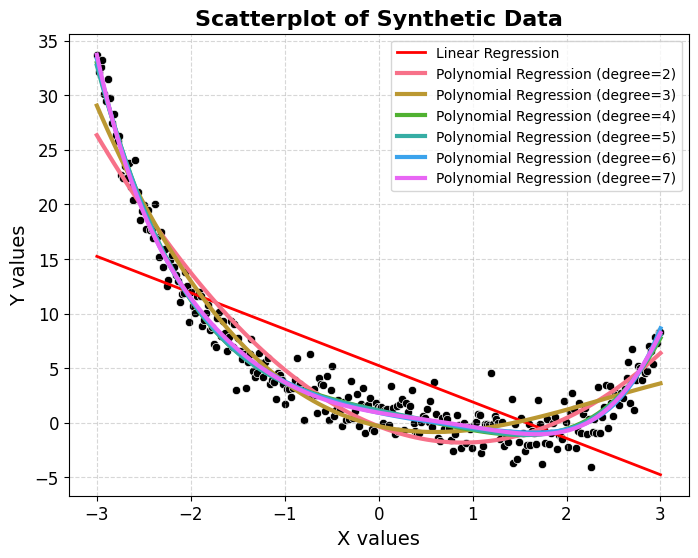

In [6]:
X_grid = np.linspace(min(X), max(X), 100).reshape(-1, 1)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="X", y="Y", color='black')
plt.xlabel("X values", fontsize=14)
plt.ylabel("Y values", fontsize=14)
plt.title("Scatterplot of Synthetic Data", fontsize=16, fontweight='bold')

# Adjust tick label font sizes
plt.xticks(fontsize=12)  # Set x-axis tick font size
plt.yticks(fontsize=12)  # Set y-axis tick font size

# Grid customization
plt.grid(True, linestyle='--', alpha=0.5)  # Add grid with dashed lines and transparency

# Plot linear regression (using X_test is not ideal for a line plot as points are unordered, better to use grid)
lin_reg_pred_grid = lin_reg.predict(X_grid)
plt.plot(X_grid, lin_reg_pred_grid, color="red", linewidth=2, label="Linear Regression")

colors = sns.color_palette("husl", len(degrees))
for i, degree in enumerate(degrees):
    # Create polynomial features for the specific degree
    poly_temp = PolynomialFeatures(degree=degree)
    X_poly_grid = poly_temp.fit_transform(X_grid)
    
    # Predict
    y_poly_grid = poly_regs[degree].predict(X_poly_grid)
    plt.plot(X_grid, y_poly_grid, color=colors[i], linewidth=3, label=f"Polynomial Regression (degree={degree})")

plt.legend()
plt.savefig("polynomial_regression_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

### 6. Pro polynomiální regresi vytvořte závislosti metrik na stupni polynomu d ∈{2, . . . , 7}.
### 7. Vytvořte obrázek se čtyřmi okny (2 řádky a 2 sloupce), kde budou zvlášť
zobrazeny grafy:
    a) MSE = f(d),
    b) RMSE = f(d),
    c) MAE = f(d),
    d) R^2 = f(d).
V každém okně použijte vhodné popisky os a název grafu.
### 8. Do každého grafu přidejte označení nejlepšího stupně d* (např. svislou čárou,
zvýrazněným bodem nebo anotací). Kritérium výběru uveďte (např. minimum
RMSE / maximum R^2).

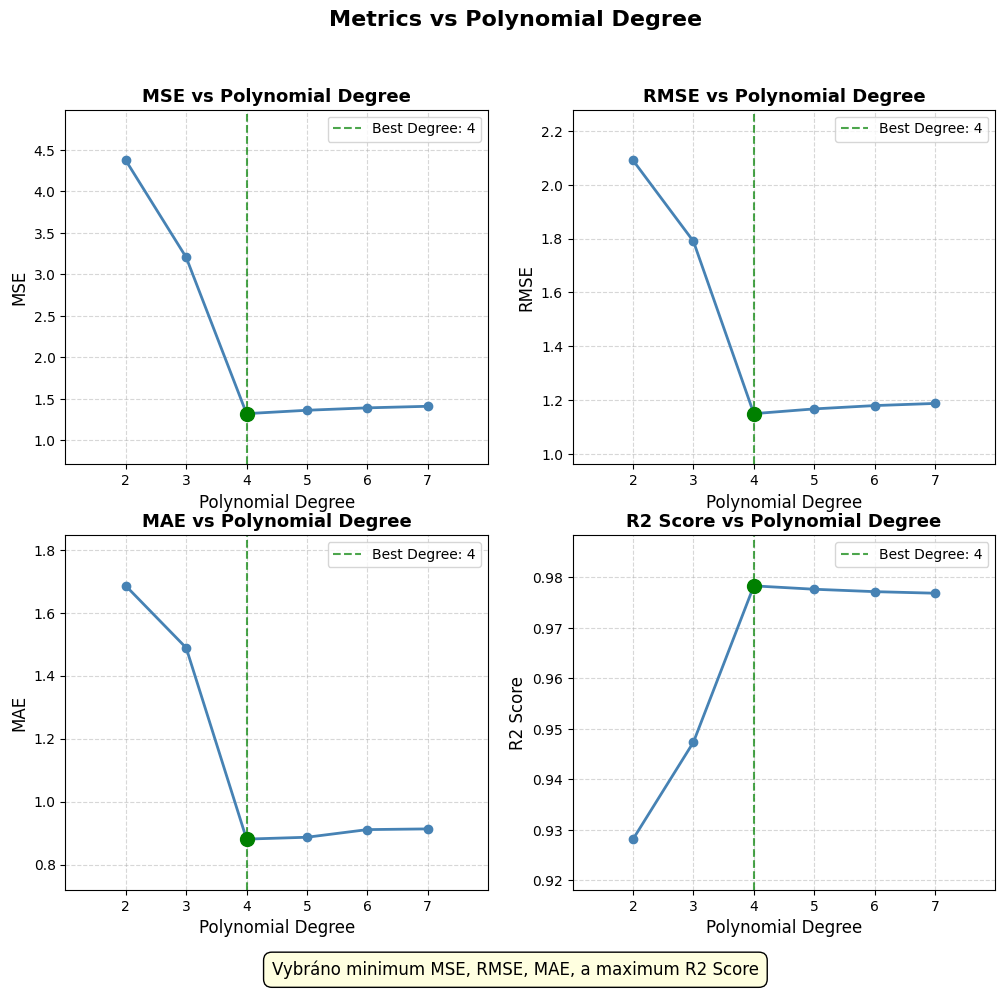

In [13]:
poly_results = results[results["Model"] != "Linear Regression"].copy() 
poly_results["Degree"] = degrees

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Metrics vs Polynomial Degree", fontsize=16, fontweight='bold')

metrics = ["MSE", "RMSE", "MAE", "R2 Score"]

# Add more margins for the axes
for ax in axes.flatten():
    ax.margins(x=0.2, y=0.2)
for ax, metric in zip(axes.flatten(), metrics):
    ax.plot(poly_results["Degree"], poly_results[metric], marker='o', linewidth=2, color='steelblue')
    
    # Identify best degree
    if metric == "R2 Score":
        best_row = poly_results.loc[poly_results[metric].idxmax()]
    else:
        best_row = poly_results.loc[poly_results[metric].idxmin()]
        
    best_color = "green"
    d_best = best_row["Degree"]
    val_best = best_row[metric]
    
    # Mark the best degree
    ax.axvline(d_best, color=best_color, linestyle='--', alpha=0.7, label=f"Best Degree: {int(d_best)}")
    ax.scatter([d_best], [val_best], color=best_color, s=100, zorder=5)
    
    ax.set_xlabel("Polynomial Degree", fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f"{metric} vs Polynomial Degree", fontsize=13, fontweight='bold')
    ax.set_xticks(degrees)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

plt.subplots_adjust(bottom=0.1)
fig.text(
    0.5,
    0.02,
    "Vybráno minimum MSE, RMSE, MAE, a maximum R2 Score",
    ha="center",
    va="center",
    fontsize=12,
    bbox=dict(facecolor="lightyellow", edgecolor="black", boxstyle="round,pad=0.5")
)

# plt.tight_layout()
plt.savefig("metrics_vs_degree.png", dpi=150)
plt.show()

### 10. Interpretace: Stručně okomentujte, jaký stupeň polynomu je nejvhodnější a proč (s ohledem na metriky a tvar regresních křivek).

Nejlepší stupeň polynomu je stupeň **4**. Má nejnižší hodnoty u všech metrik chyb a nejvyšší R^2 skóre. I dle vykreslení regresní křivky je vidět, že nejlépe indikuje trend.

# Cvičení: Vytvořte nelineární regresní model
### 1. Načtěte data misrala a BoxBOD. Vizualizujte datové sady pomocí bodového grafu.

Misrala dataset:
BoxBOD dataset:


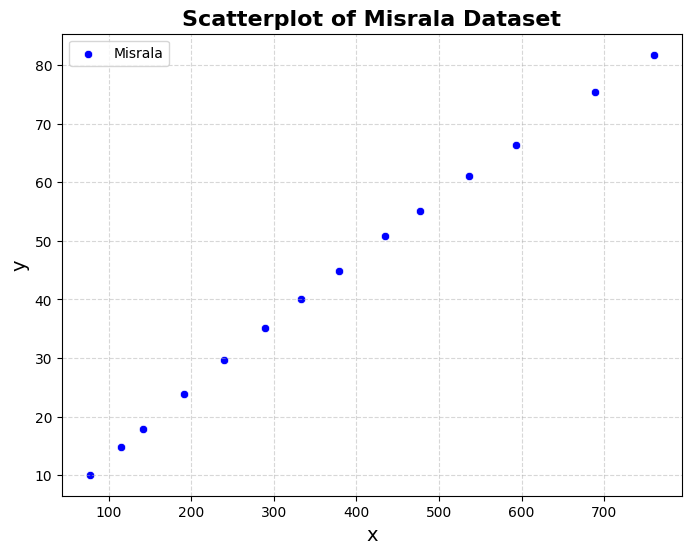

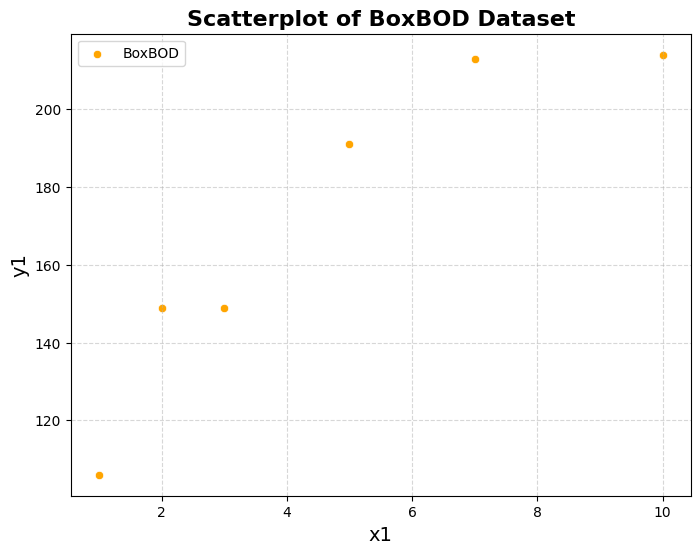

In [46]:
# Load misrala dataset
misrala = pd.read_csv("Datasets/misrala.txt", sep=r'\s+', index_col=0)
print("Misrala dataset:")
# print(misrala)
# print()

# Load BoxBOD dataset
boxbod = pd.read_csv("Datasets/BoxBOD.txt", sep=r'\s+', index_col=0)
print("BoxBOD dataset:")
# print(boxbod)

# Plot Misrala dataset
plt.figure(figsize=(8, 6))
sns.scatterplot(data=misrala, x="x", y="y", color='blue', label='Misrala')
plt.xlabel("x", fontsize=14)
plt.ylabel("y", fontsize=14)
plt.title("Scatterplot of Misrala Dataset", fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
# plt.savefig("misrala_scatter.png", dpi=300, bbox_inches='tight')
plt.show()

# Plot BoxBOD dataset
plt.figure(figsize=(8, 6))
sns.scatterplot(data=boxbod, x="x1", y="y1", color='orange', label='BoxBOD')
plt.xlabel("x1", fontsize=14)
plt.ylabel("y1", fontsize=14)
plt.title("Scatterplot of BoxBOD Dataset", fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
# plt.savefig("boxbod_scatter.png", dpi=300, bbox_inches='tight')
plt.show()

### 2. Vytvořte polynomiální a nelineární regresní modely. Funkce nelineární regrese je definována jako:
_y = a(1 − e^(−bx) ) + ε_

In [47]:
# Polynomial regression on misrala dataset
degrees_mis = [2, 3, 4, 5, 6, 7, 8, 9, 10]
errors_mis = []

# Prepare features and target for misrala
X_mis = misrala["x"].values.reshape(-1, 1)
y_mis = misrala["y"].values

# Train/test split for misrala
X_train_mis, X_test_mis, y_train_mis, y_test_mis = train_test_split(X_mis, y_mis, test_size=0.2, random_state=42)

for degree in degrees_mis:
    poly_mis = PolynomialFeatures(degree=degree)
    X_poly_train_mis = poly_mis.fit_transform(X_train_mis)
    X_poly_test_mis = poly_mis.transform(X_test_mis)

    poly_reg_mis = LinearRegression()
    poly_reg_mis.fit(X_poly_train_mis, y_train_mis)

    y_poly_pred_mis = poly_reg_mis.predict(X_poly_test_mis)
    mse_poly_mis = mean_squared_error(y_test_mis, y_poly_pred_mis)
    errors_mis.append(mse_poly_mis)

optimal_degree_mis = degrees_mis[np.argmin(errors_mis)]

print(f"Optimal degree for polynomial regression on misrala: {optimal_degree_mis}")

# Refit polynomial model with optimal degree on misrala
poly_mis_opt = PolynomialFeatures(degree=optimal_degree_mis)
X_poly_train_mis = poly_mis_opt.fit_transform(X_train_mis)
X_poly_test_mis = poly_mis_opt.transform(X_test_mis)

poly_reg_mis_opt = LinearRegression()
poly_reg_mis_opt.fit(X_poly_train_mis, y_train_mis)
y_poly_pred_mis_opt = poly_reg_mis_opt.predict(X_poly_test_mis)

mse_poly_mis_opt = mean_squared_error(y_test_mis, y_poly_pred_mis_opt)
rmse_poly_mis_opt = np.sqrt(mse_poly_mis_opt)
mae_poly_mis_opt = mean_absolute_error(y_test_mis, y_poly_pred_mis_opt)
r2_poly_mis_opt = r2_score(y_test_mis, y_poly_pred_mis_opt)

print(f"Misrala Polynomial Regression (degree={optimal_degree_mis}) MSE: {np.round(mse_poly_mis_opt,3)}, RMSE: {np.round(rmse_poly_mis_opt,3)}, MAE: {np.round(mae_poly_mis_opt,3)}, R2: {np.round(r2_poly_mis_opt,3)}")



Optimal degree for polynomial regression on misrala: 3
Misrala Polynomial Regression (degree=3) MSE: 0.002, RMSE: 0.046, MAE: 0.043, R2: 1.0


In [48]:
def model_func(conc, a, b):
    return a * (1 - np.exp(-b * conc))

concM = np.array(misrala["x"]).flatten()
rateM = np.array(misrala["y"]).flatten()

initial_guess = [1, 0.1]
bounds = (0, np.inf)

# Fit on all data (curve_fit is not a train/test workflow)
param_opt_misrala, param_cov_misrala = curve_fit(model_func, concM, rateM, p0=initial_guess, bounds=bounds, maxfev=10000)

a_opt_misrala, b_opt_misrala = param_opt_misrala
print(f"Optimized parameters for misrala: a = {a_opt_misrala}, b = {b_opt_misrala}")

misrala_rate_pred = model_func(concM, *param_opt_misrala)

# Calculate residuals
misrala_residuals_nonlinear_1 = rateM - misrala_rate_pred

misrala_mse_nonlinear  = mean_squared_error(rateM, misrala_rate_pred)
misrala_rmse_nonlinear = np.sqrt(misrala_mse_nonlinear)
misrala_mae_nonlinear  = mean_absolute_error(rateM, misrala_rate_pred)
misrala_r2_nonlinear   = r2_score(rateM, misrala_rate_pred)

print(f"Nonlinear Regression MSE: {misrala_mse_nonlinear}, RMSE: {misrala_rmse_nonlinear}, MAE: {misrala_mae_nonlinear}, R2: {misrala_r2_nonlinear}")

Optimized parameters for misrala: a = 238.94212157243592, b = 0.0005501564522522322
Nonlinear Regression MSE: 0.008896527781749122, RMSE: 0.09432140680539663, MAE: 0.09052976022062913, R2: 0.9999815801100362


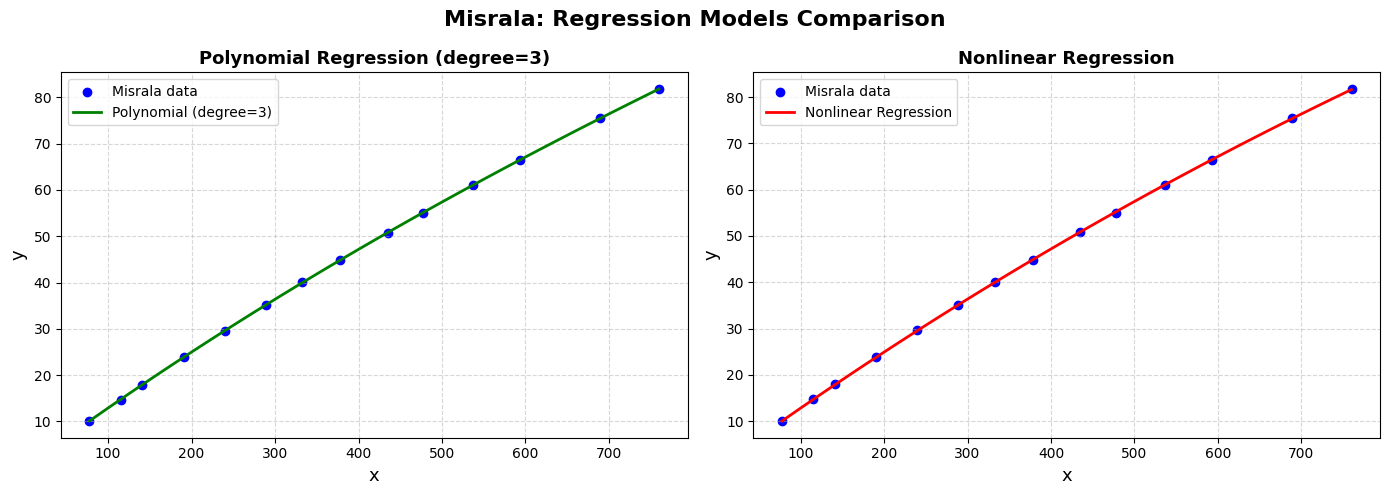

                Model    MSE   RMSE    MAE  R2
Polynomial (degree=3) 0.0021 0.0463 0.0432 1.0
            Nonlinear 0.0089 0.0943 0.0905 1.0


In [49]:

# Prepare grid for smooth curves
X_grid_mis = np.linspace(X_mis.min(), X_mis.max(), 100).reshape(-1, 1)
X_poly_grid_mis = poly_mis_opt.transform(X_grid_mis)
y_poly_grid_mis = poly_reg_mis_opt.predict(X_poly_grid_mis)
y_nonlinear_grid_mis = model_func(X_grid_mis.flatten(), *param_opt_misrala)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Misrala: Regression Models Comparison", fontsize=16, fontweight='bold')

# --- Polynomial ---
ax1.scatter(misrala["x"], misrala["y"], color="blue", label="Misrala data")
ax1.plot(X_grid_mis, y_poly_grid_mis, color="green", linewidth=2,
         label=f"Polynomial (degree={optimal_degree_mis})")
ax1.set_xlabel("x", fontsize=13)
ax1.set_ylabel("y", fontsize=13)
ax1.set_title(f"Polynomial Regression (degree={optimal_degree_mis})", fontsize=13, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

# --- Nonlinear ---
ax2.scatter(misrala["x"], misrala["y"], color="blue", label="Misrala data")
ax2.plot(X_grid_mis, y_nonlinear_grid_mis, color="red", linewidth=2, label="Nonlinear Regression")
ax2.set_xlabel("x", fontsize=13)
ax2.set_ylabel("y", fontsize=13)
ax2.set_title("Nonlinear Regression", fontsize=13, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.savefig("misrala.png", dpi=300, bbox_inches='tight')
plt.show()

# --- Metrics table ---
metrics_table = pd.DataFrame({
    "Model": [f"Polynomial (degree={optimal_degree_mis})", "Nonlinear"],
    "MSE":  [np.round(mse_poly_mis_opt, 4),     np.round(misrala_mse_nonlinear, 4)],
    "RMSE": [np.round(rmse_poly_mis_opt, 4),    np.round(misrala_rmse_nonlinear, 4)],
    "MAE":  [np.round(mae_poly_mis_opt, 4),     np.round(misrala_mae_nonlinear, 4)],
    "R2":   [np.round(r2_poly_mis_opt, 4),      np.round(misrala_r2_nonlinear, 4)],
})
print(metrics_table.to_string(index=False))


In [50]:

concB = np.array(boxbod["x1"]).flatten()
rateB = np.array(boxbod["y1"]).flatten()

initial_guess = [1, 0.1]
bounds = (0, np.inf)

# Fit on all data (curve_fit is not a train/test workflow; BoxBOD has only 6 points)
param_opt_boxbod, param_cov_boxbod = curve_fit(model_func, concB, rateB, p0=initial_guess, bounds=bounds, maxfev=10000)

a_opt_boxbod, b_opt_boxbod = param_opt_boxbod
print(f"Optimized parameters for boxbod: a = {a_opt_boxbod}, b = {b_opt_boxbod}")

boxbod_rate_pred = model_func(concB, *param_opt_boxbod)

# Calculate residuals
boxbod_residuals_nonlinear = rateB - boxbod_rate_pred

boxbod_mse_nonlinear  = mean_squared_error(rateB, boxbod_rate_pred)
boxbod_rmse_nonlinear = np.sqrt(boxbod_mse_nonlinear)
boxbod_mae_nonlinear  = mean_absolute_error(rateB, boxbod_rate_pred)
boxbod_r2_nonlinear   = r2_score(rateB, boxbod_rate_pred)

print(f"Nonlinear Regression MSE: {boxbod_mse_nonlinear}, RMSE: {boxbod_rmse_nonlinear}, MAE: {boxbod_mae_nonlinear}, R2: {boxbod_r2_nonlinear}")


Optimized parameters for boxbod: a = 209.1452962839511, b = 0.5709181442449838
Nonlinear Regression MSE: 149.9300447984052, RMSE: 12.244592471716043, MAE: 10.569312996187954, R2: 0.9022549508739118


In [51]:

# Polynomial regression on BoxBOD dataset
degrees_box = [2, 3, 4, 5, 6, 7, 8, 9, 10]
errors_box = []

# Prepare features and target for BoxBOD
X_box = boxbod["x1"].values.reshape(-1, 1)
y_box = boxbod["y1"].values

# Train/test split for BoxBOD
X_train_box, X_test_box, y_train_box, y_test_box = train_test_split(X_box, y_box, test_size=0.2, random_state=42)

# Linear regression baseline for BoxBOD
lin_reg_box = LinearRegression()
lin_reg_box.fit(X_train_box, y_train_box)

for degree in degrees_box:
    poly_box = PolynomialFeatures(degree=degree)
    X_poly_train_box = poly_box.fit_transform(X_train_box)
    X_poly_test_box = poly_box.transform(X_test_box)

    poly_reg_box = LinearRegression()
    poly_reg_box.fit(X_poly_train_box, y_train_box)

    y_poly_pred_box = poly_reg_box.predict(X_poly_test_box)
    mse_poly_box = mean_squared_error(y_test_box, y_poly_pred_box)
    errors_box.append(mse_poly_box)

optimal_degree_box = degrees_box[np.argmin(errors_box)]
print(f"Optimal degree for polynomial regression on BoxBOD: {optimal_degree_box}")

# Refit polynomial model with optimal degree on BoxBOD
poly_box_opt = PolynomialFeatures(degree=optimal_degree_box)
X_poly_train_box = poly_box_opt.fit_transform(X_train_box)
X_poly_test_box = poly_box_opt.transform(X_test_box)

poly_reg_box_opt = LinearRegression()
poly_reg_box_opt.fit(X_poly_train_box, y_train_box)
y_poly_pred_box_opt = poly_reg_box_opt.predict(X_poly_test_box)

mse_poly_box_opt = mean_squared_error(y_test_box, y_poly_pred_box_opt)
rmse_poly_box_opt = np.sqrt(mse_poly_box_opt)
mae_poly_box_opt = mean_absolute_error(y_test_box, y_poly_pred_box_opt)
r2_poly_box_opt = r2_score(y_test_box, y_poly_pred_box_opt)

print(f"BoxBOD Polynomial Regression (degree={optimal_degree_box}) MSE: {np.round(mse_poly_box_opt,3)}, RMSE: {np.round(rmse_poly_box_opt,3)}, MAE: {np.round(mae_poly_box_opt,3)}, R2: {np.round(r2_poly_box_opt,3)}")


Optimal degree for polynomial regression on BoxBOD: 4
BoxBOD Polynomial Regression (degree=4) MSE: 265.801, RMSE: 16.303, MAE: 12.011, R2: 0.425


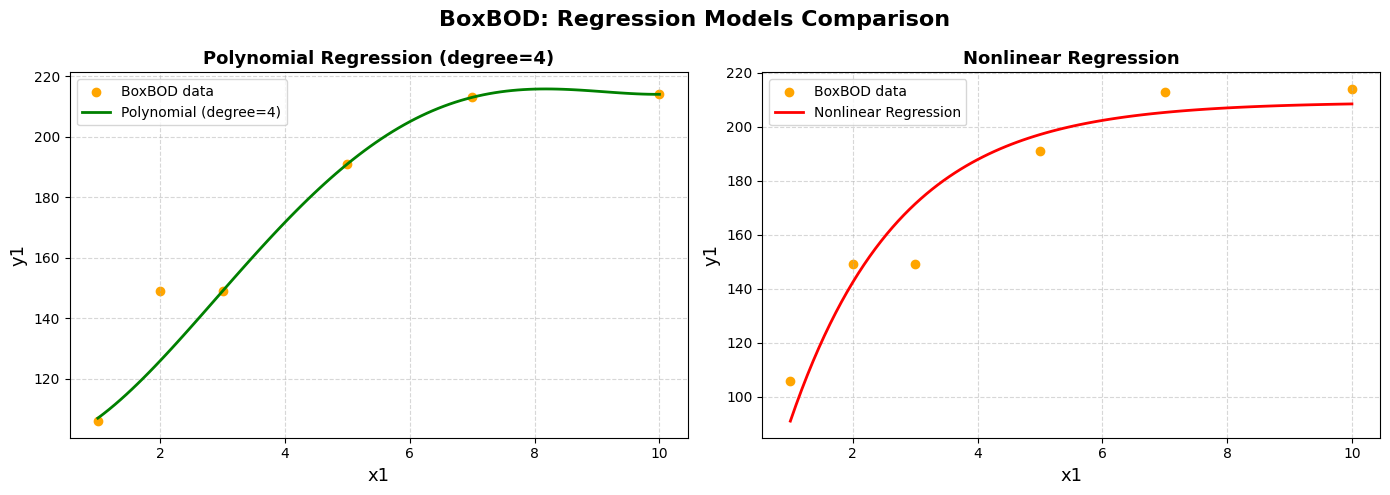

                Model      MSE    RMSE     MAE     R2
Polynomial (degree=4) 265.8013 16.3034 12.0112 0.4250
            Nonlinear 149.9300 12.2446 10.5693 0.9023


In [52]:

# Prepare grid for smooth curves
X_grid_box = np.linspace(X_box.min(), X_box.max(), 100).reshape(-1, 1)
X_poly_grid_box = poly_box_opt.transform(X_grid_box)
y_poly_grid_box = poly_reg_box_opt.predict(X_poly_grid_box)
y_nonlinear_grid_box = model_func(X_grid_box.flatten(), *param_opt_boxbod)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("BoxBOD: Regression Models Comparison", fontsize=16, fontweight='bold')

# --- Polynomial ---
ax1.scatter(boxbod["x1"], boxbod["y1"], color="orange", label="BoxBOD data")
ax1.plot(X_grid_box, y_poly_grid_box, color="green", linewidth=2,
         label=f"Polynomial (degree={optimal_degree_box})")
ax1.set_xlabel("x1", fontsize=13)
ax1.set_ylabel("y1", fontsize=13)
ax1.set_title(f"Polynomial Regression (degree={optimal_degree_box})", fontsize=13, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

# --- Nonlinear ---
ax2.scatter(boxbod["x1"], boxbod["y1"], color="orange", label="BoxBOD data")
ax2.plot(X_grid_box, y_nonlinear_grid_box, color="red", linewidth=2, label="Nonlinear Regression")
ax2.set_xlabel("x1", fontsize=13)
ax2.set_ylabel("y1", fontsize=13)
ax2.set_title("Nonlinear Regression", fontsize=13, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.savefig("boxbod.png", dpi=300, bbox_inches='tight')
plt.show()

# --- Metrics table ---
metrics_table_box = pd.DataFrame({
    "Model": [f"Polynomial (degree={optimal_degree_box})", "Nonlinear"],
    "MSE":  [np.round(mse_poly_box_opt, 4),  np.round(boxbod_mse_nonlinear, 4)],
    "RMSE": [np.round(rmse_poly_box_opt, 4), np.round(boxbod_rmse_nonlinear, 4)],
    "MAE":  [np.round(mae_poly_box_opt, 4),  np.round(boxbod_mae_nonlinear, 4)],
    "R2":   [np.round(r2_poly_box_opt, 4),   np.round(boxbod_r2_nonlinear, 4)],
})
print(metrics_table_box.to_string(index=False))
